In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import json

In [9]:
matrix_data = {
 'CADRL-Style': pd.read_excel("CADRL-style.xlsx", index_col=0).values,
 'DQN (Greedy)': pd.read_excel("DQN (Greedy).xlsx", index_col=0).values,
 'CADRL-Style_single': pd.read_excel("CADRL-style_single.xlsx", index_col=0).values,
 'DQN (Greedy)_single': pd.read_excel("DQN (Greedy)_single.xlsx", index_col=0).values,
 'Trivial': pd.read_excel("Trivial.xlsx", index_col=0).values
}

matrix_data

{'CADRL-Style': array([[0.02585551, 0.01011804, 0.00165289, 0.00278422, 0.00290792,
         0.01639344],
        [0.03105727, 0.01744604, 0.02118056, 0.00974771, 0.00628853,
         0.00570265],
        [0.02233618, 0.01301345, 0.01622678, 0.02020906, 0.01820952,
         0.01125887],
        [0.0554023 , 0.03683409, 0.02310867, 0.0240566 , 0.0168428 ,
         0.01462069],
        [0.04856721, 0.03035556, 0.02853583, 0.02396739, 0.02079167,
         0.02219215],
        [0.07090449, 0.04089302, 0.03744681, 0.02651515, 0.03899018,
         0.02962046]]),
 'DQN (Greedy)': array([[0.01545064, 0.01323529, 0.01986456, 0.00229885, 0.00662768,
         0.00787037],
        [0.04259259, 0.03203661, 0.01341991, 0.01271676, 0.00743405,
         0.01102041],
        [0.06245614, 0.02020774, 0.02317189, 0.02352941, 0.00926485,
         0.00691271],
        [0.10053476, 0.04497908, 0.02347447, 0.02100977, 0.02339688,
         0.01545139],
        [0.12025424, 0.04938272, 0.0389491 , 0.04293839, 

In [10]:
import pandas as pd
# Values
BOARD_SIZES = [50,60,70,80,90,100]
ROBOT_COUNTS = [5,10,15,20,25,30]
# Setup
state_dim = (2 * 10 + 1) ** 2 * 2 + 2
action_dim = 8
df_dict = {}
for name, matrix in matrix_data.items():
    df_dict[name] = pd.DataFrame(
        matrix,
        index=[f'{r} robots' for r in ROBOT_COUNTS],
        columns=[f'board={b}' for b in BOARD_SIZES]
    )

# Preview
for name, df in df_dict.items():
    print(f"\n{name}")
    print(df)


CADRL-Style
           board=50  board=60  board=70  board=80  board=90  board=100
5 robots   0.025856  0.010118  0.001653  0.002784  0.002908   0.016393
10 robots  0.031057  0.017446  0.021181  0.009748  0.006289   0.005703
15 robots  0.022336  0.013013  0.016227  0.020209  0.018210   0.011259
20 robots  0.055402  0.036834  0.023109  0.024057  0.016843   0.014621
25 robots  0.048567  0.030356  0.028536  0.023967  0.020792   0.022192
30 robots  0.070904  0.040893  0.037447  0.026515  0.038990   0.029620

DQN (Greedy)
           board=50  board=60  board=70  board=80  board=90  board=100
5 robots   0.015451  0.013235  0.019865  0.002299  0.006628   0.007870
10 robots  0.042593  0.032037  0.013420  0.012717  0.007434   0.011020
15 robots  0.062456  0.020208  0.023172  0.023529  0.009265   0.006913
20 robots  0.100535  0.044979  0.023474  0.021010  0.023397   0.015451
25 robots  0.120254  0.049383  0.038949  0.042938  0.039226   0.031326
30 robots  0.119495  0.070310  0.053366  0.043271 

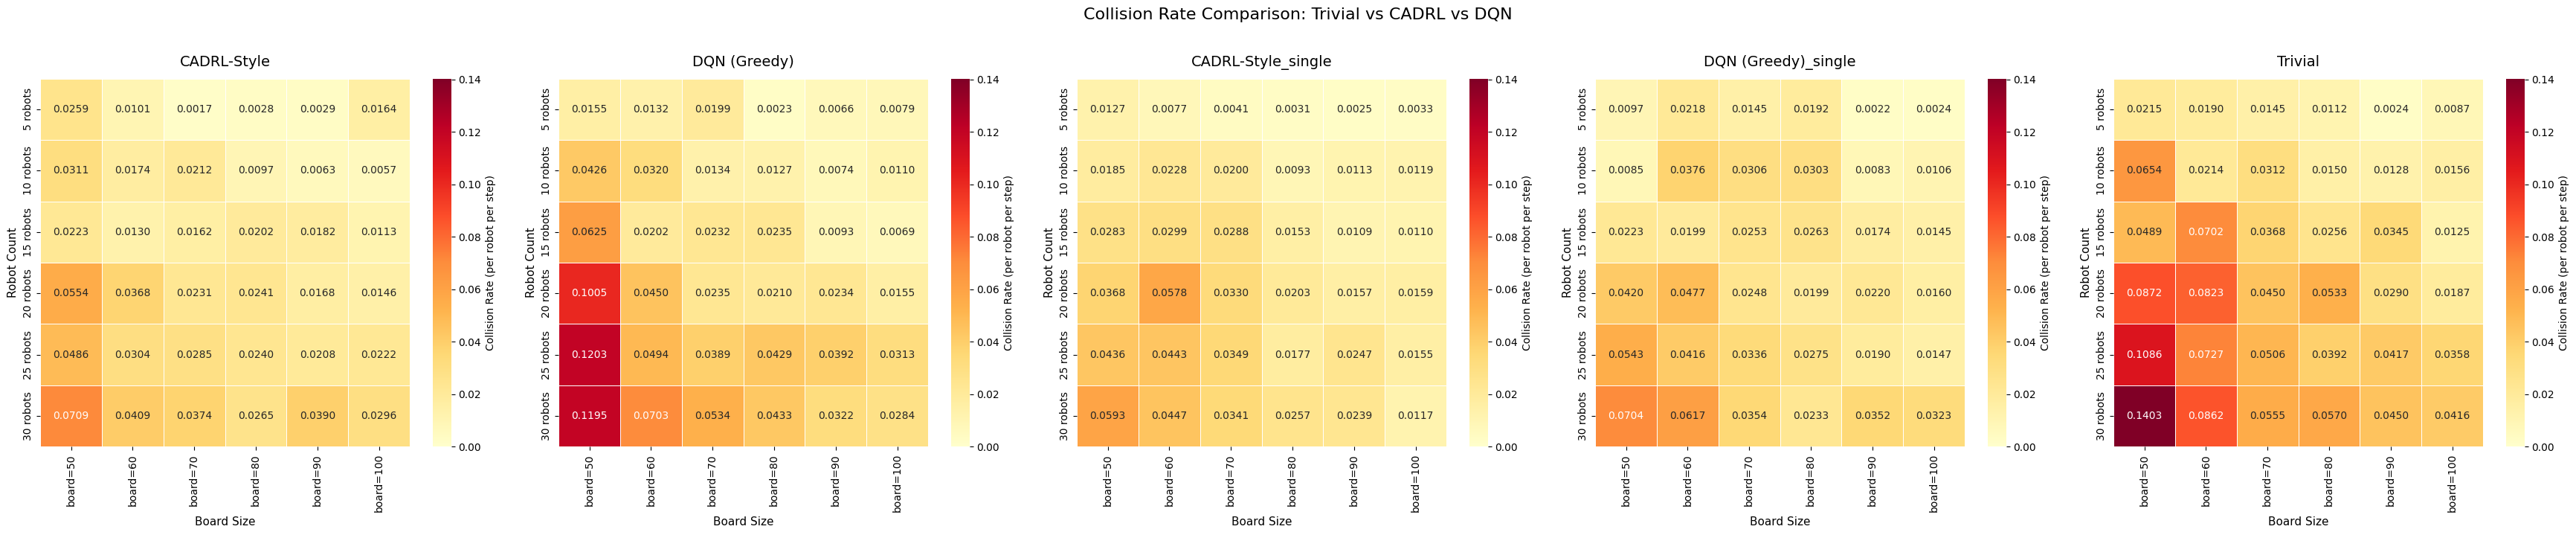

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(df_dict), figsize=(7*len(df_dict), 7))

for ax, (name, df) in zip(axes, df_dict.items()):
    sns.heatmap(
        df,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='YlOrRd',
        vmin=0,
        vmax=max(m.max() for m in matrix_data.values()),  # shared scale
        linewidths=0.5,
        cbar_kws={'label': 'Collision Rate (per robot per step)'}
    )
    ax.set_title(name, fontsize=14, pad=12)
    ax.set_xlabel('Board Size', fontsize=11)
    ax.set_ylabel('Robot Count', fontsize=11)

plt.suptitle('Collision Rate Comparison: Trivial vs CADRL vs DQN', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
def plot_heatmap(matrix, colorbar_kws, title, x_lab, y_lab):
    fig, ax = plt.subplots(figsize=(9, 6))

    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn',   # red = DQN better, green = CADRL better
        center=0,
        linewidths=0.5,
        cbar_kws=colorbar_kws
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_lab, fontsize=11)
    ax.set_ylabel(y_lab, fontsize=11)
    plt.tight_layout()
    plt.show()

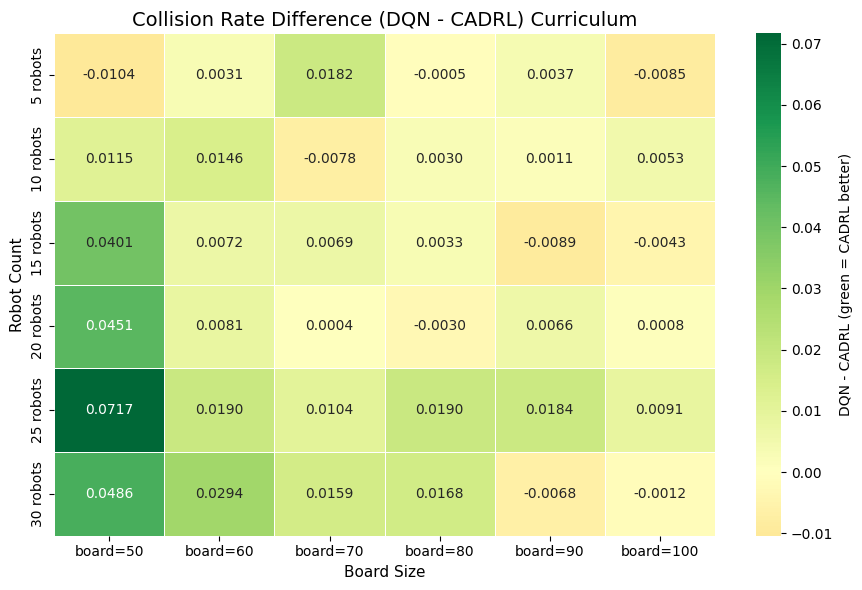

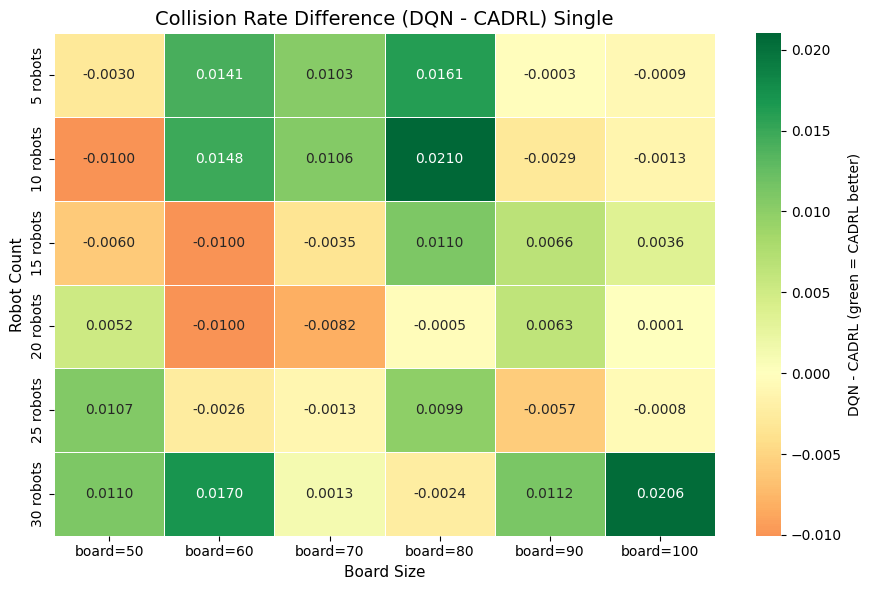

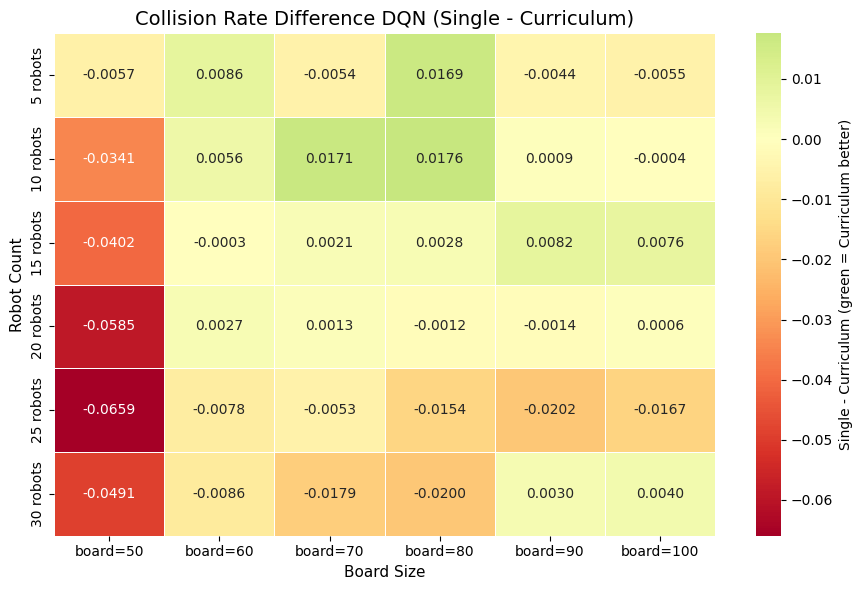

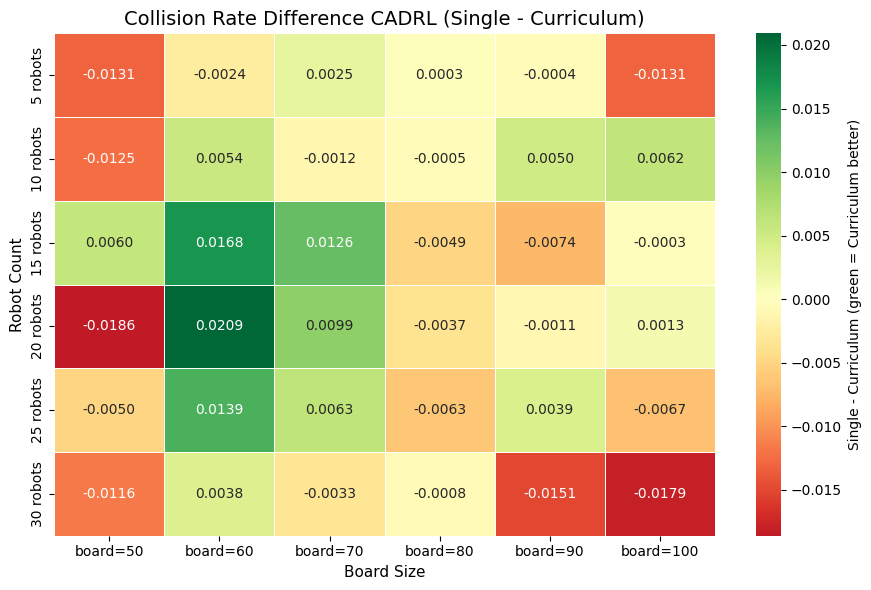

In [16]:
diff_df = df_dict['DQN (Greedy)'] - df_dict['CADRL-Style']  # positive = CADRL better
diff_df_single = df_dict['DQN (Greedy)_single'] - df_dict['CADRL-Style_single']  # positive = CADRL better

diff_df_DQN_curr = df_dict['DQN (Greedy)_single'] - df_dict['DQN (Greedy)']  # positive = CADRL better
diff_df_CADRL_curr = df_dict['CADRL-Style_single'] - df_dict['CADRL-Style']  # positive = CADRL better

plot_heatmap(diff_df, {'label': 'DQN - CADRL (green = CADRL better)'}, 'Collision Rate Difference (DQN - CADRL) Curriculum', 'Board Size', 'Robot Count')
plot_heatmap(diff_df_single, {'label': 'DQN - CADRL (green = CADRL better)'}, 'Collision Rate Difference (DQN - CADRL) Single', 'Board Size', 'Robot Count')
plot_heatmap(diff_df_DQN_curr, {'label': 'Single - Curriculum (green = Curriculum better)'}, 'Collision Rate Difference DQN (Single - Curriculum)', 'Board Size', 'Robot Count')
plot_heatmap(diff_df_CADRL_curr, {'label': 'Single - Curriculum (green = Curriculum better)'}, 'Collision Rate Difference CADRL (Single - Curriculum)', 'Board Size', 'Robot Count')


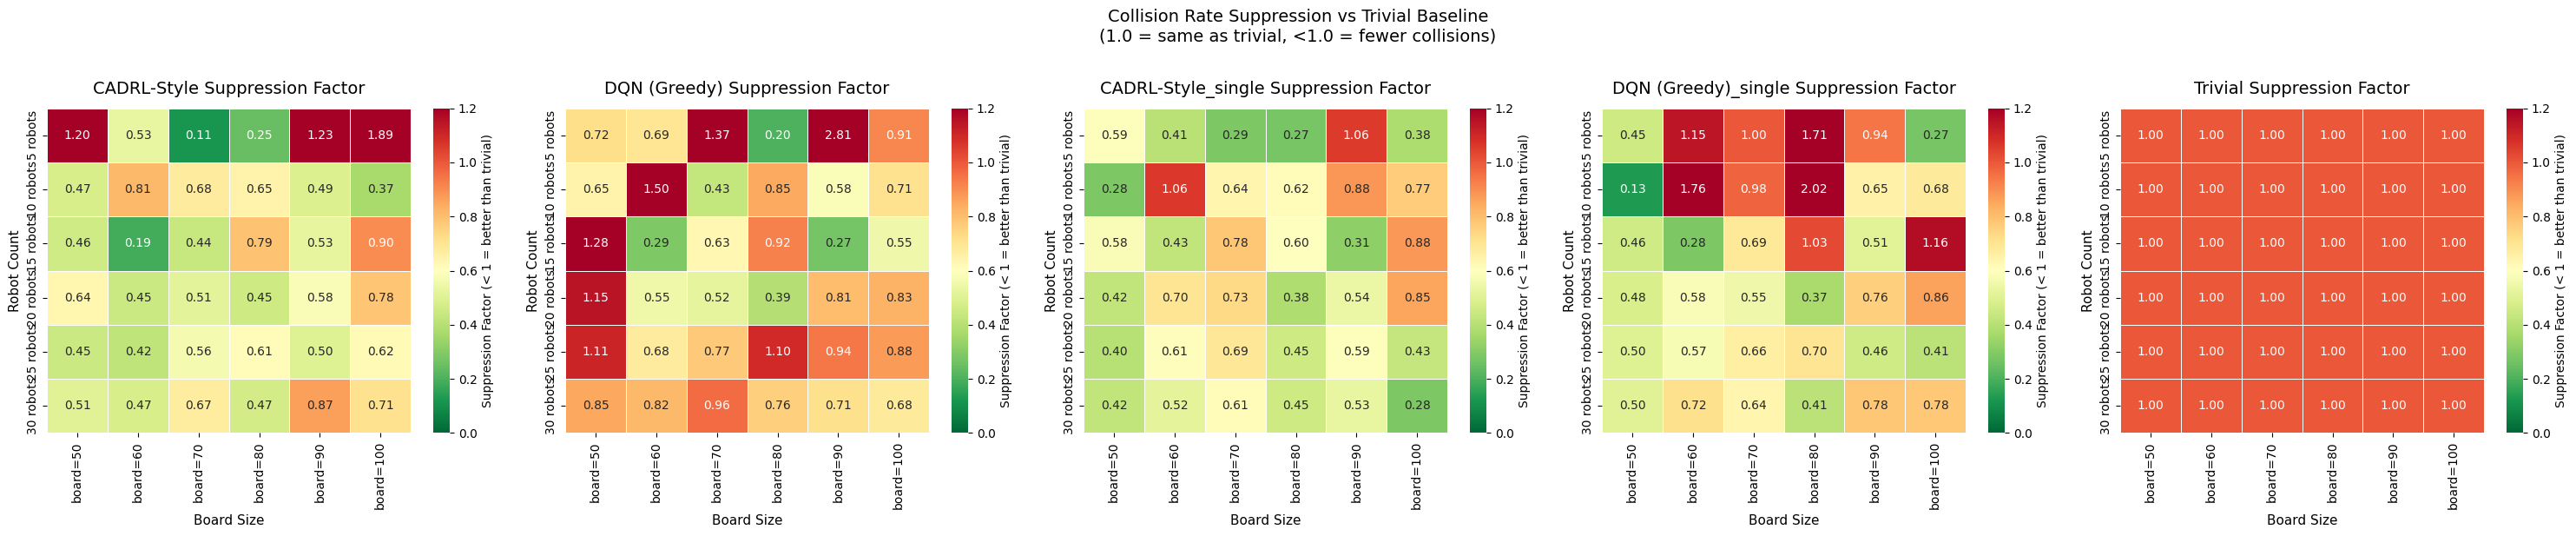

In [17]:
suppression = {
    name: df_dict[name] / df_dict['Trivial']
    for name in df_dict.keys()
}

fig, axes = plt.subplots(1, len(suppression), figsize=(6*len(suppression), 6))

for ax, (name, df) in zip(axes, suppression.items()):
    sns.heatmap(
        df,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn_r',  # green = low suppression (better), red = high (worse)
        vmin=0,
        vmax=1.2,          # >1 means worse than trivial
        linewidths=0.5,
        cbar_kws={'label': 'Suppression Factor (< 1 = better than trivial)'}
    )
    ax.set_title(f'{name} Suppression Factor', fontsize=14, pad=12)
    ax.set_xlabel('Board Size', fontsize=11)
    ax.set_ylabel('Robot Count', fontsize=11)

plt.suptitle('Collision Rate Suppression vs Trivial Baseline\n(1.0 = same as trivial, <1.0 = fewer collisions)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

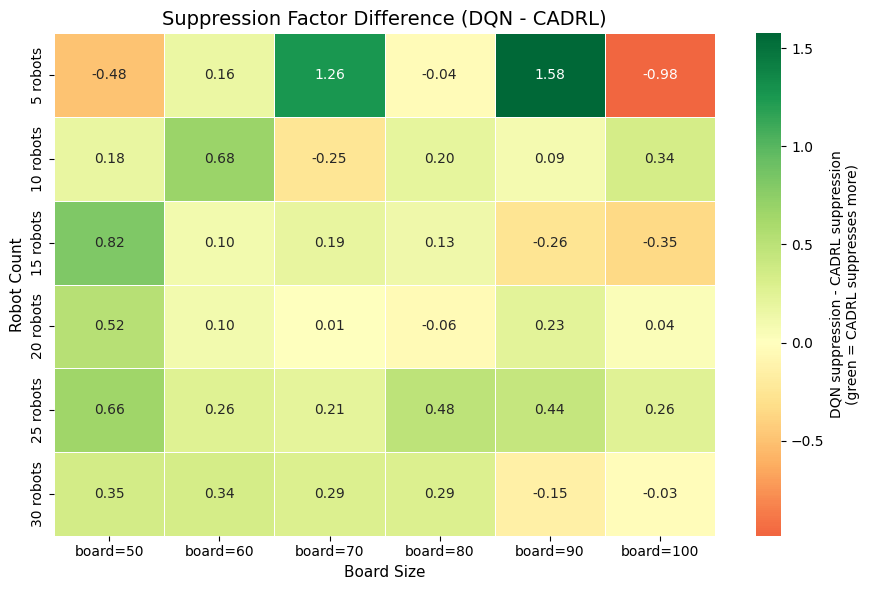

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

diff = suppression['DQN (Greedy)'] - suppression['CADRL-Style']  # positive = CADRL suppresses more

sns.heatmap(
    diff,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',   # green = CADRL better, red = DQN better
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'DQN suppression - CADRL suppression\n(green = CADRL suppresses more)'}
)
ax.set_title('Suppression Factor Difference (DQN - CADRL)', fontsize=14)
ax.set_xlabel('Board Size', fontsize=11)
ax.set_ylabel('Robot Count', fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
print( np.mean(suppression['CADRL-Style']), np.median(suppression['CADRL-Style']) )
print( np.mean(suppression['DQN (Greedy)']),np.median(suppression['DQN (Greedy)']))
print( np.mean(suppression['CADRL-Style_single']), np.median(suppression['CADRL-Style_single']) )
print( np.mean(suppression['DQN (Greedy)_single']),np.median(suppression['DQN (Greedy)_single']))

0.618546939267122 0.5298642090000001
0.829343392119691 0.7643814322995444
0.568135963490474 0.5601542923099492
0.7386719374357664 0.6580377404064839


In [2]:
import pandas as pd
import numpy as np
from math import comb
from sklearn.model_selection import train_test_split
from scipy.optimize import curve_fit

trivial = pd.read_excel("Trivial.xlsx", index_col=0)
trivial.index = [5, 10, 15, 20, 25, 30]
trivial.columns = [50, 60, 70, 80, 90, 100]

rows = []
for n in trivial.index:
    for b in trivial.columns:
        rows.append({'N': n, 'beta': b, 'collision_rate': trivial.loc[n, b]})
df = pd.DataFrame(rows)

# Fit alpha per (N, beta) directly against the real collision rate:
# collision_rate = alpha * C(N,2) / A  =>  alpha = collision_rate * A / C(N,2)
df['alpha'] = 2 * df['collision_rate'] * (df['beta']**2) / df['N'].apply(lambda n: comb(int(n), 2))
print(df[['N', 'beta', 'collision_rate', 'alpha']])

# Fit a smooth power-law alpha(N, beta), same held-out validation as before
def alpha_model(X, c, p, q):
    N, beta = X
    A = beta**2
    return c * (A**p) * (N**q)

train, test = train_test_split(df, test_size=0.3, random_state=42)
popt, _ = curve_fit(alpha_model, (train['N'], train['beta']), train['alpha'], maxfev=5000)

pred_test = alpha_model((test['N'], test['beta']), *popt)
ss_res = ((test['alpha'] - pred_test)**2).sum()
ss_tot = ((test['alpha'] - test['alpha'].mean())**2).sum()
r2_holdout = 1 - ss_res / ss_tot
print(f"\nHeld-out R² (alpha fit on real Trivial data): {r2_holdout:.4f}")
print(f"Fitted params (c, p, q): {popt}")

# Reconstruct CP prediction and compare directly to real collision rate, same units now
df['cp_predicted_rate'] = alpha_model((df['N'], df['beta']), *popt) * df['N'].apply(lambda n: comb(int(n), 2)) / (2 * df['beta']**2)
df['mae'] = (df['cp_predicted_rate'] - df['collision_rate']).abs()
print(f"MAE (corrected): {df['mae'].mean():.5f}")

     N  beta  collision_rate      alpha
0    5    50        0.021463  10.731707
1    5    60        0.019048  13.714286
2    5    70        0.014474  14.184211
3    5    80        0.011230  14.374332
4    5    90        0.002360   3.823009
5    5   100        0.008654  17.307692
6   10    50        0.065385   7.264957
7   10    60        0.021429   3.428571
8   10    70        0.031229   6.801034
9   10    80        0.015029   4.274888
10  10    90        0.012788   4.603581
11  10   100        0.015550   6.911217
12  15    50        0.048949   2.330902
13  15    60        0.070175   4.812030
14  15    70        0.036836   3.438041
15  15    80        0.025597   3.120389
16  15    90        0.034453   5.315615
17  15   100        0.012500   2.380952
18  20    50        0.087229   2.295512
19  20    60        0.082308   3.119028
20  20    70        0.044951   2.318532
21  20    80        0.053297   3.590515
22  20    90        0.029040   2.476077
23  20   100        0.018665   1.964754


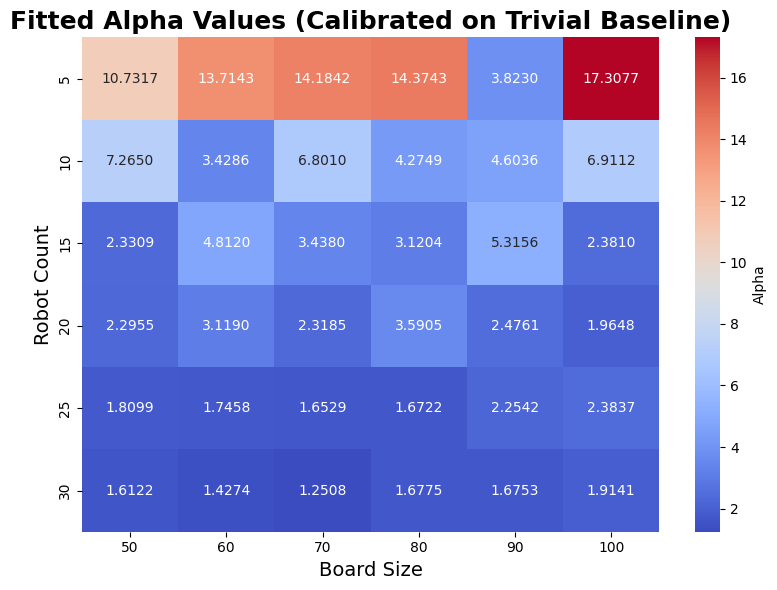

In [5]:
pivot_alpha = df.pivot(index='N', columns='beta', values='alpha')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_alpha, annot=True, fmt='.4f', cmap='coolwarm',
            cbar_kws={'label': 'Alpha'})
plt.title('Fitted Alpha Values (Calibrated on Trivial Baseline)',
          fontsize=18, fontweight='bold')
plt.xlabel('Board Size', fontsize=14, fontweight='normal')
plt.ylabel('Robot Count', fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('fitted_alpha_trivial.png', dpi=200)
plt.show()